In [210]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm
from skimage.feature import hog
import numpy as np
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics as tm
from transformers import AutoModel, AutoImageProcessor

In [211]:
root_path = "/home/stefan/Downloads/dataset-b22bcb58-37e6-4196-adec-3bcb60881e46"
device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.random.manual_seed(seed)

# Data

In [212]:
le = LabelEncoder()

full_train_df = pd.read_csv(f"{root_path}/train.csv")
le.fit(full_train_df["Type"])

train_df, val_df = train_test_split(
    full_train_df, test_size=0.15, random_state=seed, stratify=full_train_df["Type"]
)
train_df.head()

,SampleID,ImagePath,Type
403,37,images/000037.png,Ghost
640,21,images/000021.png,Rock
612,475,images/000475.png,Fire
122,479,images/000479.png,Flying
356,516,images/000516.png,Normal


<Axes: >

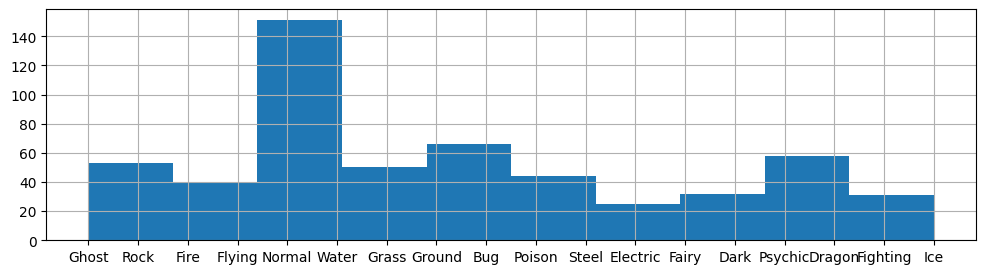

In [213]:
plt.figure(figsize=(12, 3))
train_df["Type"].hist()

In [214]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=le.classes_,
    y=train_df["Type"],
)


class_weights

array([ 0.67777778,  1.69444444,  1.69444444,  1.22      ,  2.17857143,
        1.90625   ,  0.82432432, 15.25      ,  1.60526316,  0.61      ,
        1.45238095,  2.03333333,  0.42361111,  1.27083333,  0.7625    ,
        0.89705882,  1.525     ,  0.38607595])

In [215]:
def get_cb_weights(df, label_encoder, beta=0.999):
    counts = df["Type"].value_counts().reindex(label_encoder.classes_).values
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / np.array(effective_num)
    # Normalize weights to sum to number of classes
    weights = weights / np.sum(weights) * len(counts)
    return torch.tensor(weights, dtype=torch.float32)


# Common beta values are 0.9, 0.99, 0.999, 0.9999
cb_weights = get_cb_weights(train_df, le, beta=0.999).to(device)
cb_weights

tensor([0.3401, 0.8388, 0.8388, 0.6061, 1.0764, 0.9428, 0.4120, 7.4895, 0.7951,
        0.3068, 0.7201, 1.0051, 0.2154, 0.6310, 0.3816, 0.4476, 0.7557, 0.1970],
       device='cuda:0')

In [216]:
class PokemonDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train=False):
        super().__init__()

        self.df = df

        self.transforms = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ]) if not is_train else v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(15),
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ]) 

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = f"{root_path}/{row['ImagePath']}"
        img = Image.open(img_path).convert("RGBA")
        # Create a white background
        white_bg = Image.new("RGBA", img.size, "WHITE")
        # Paste the image on top of the background using alpha channel as mask
        white_bg.paste(img, (0, 0), img)
        img = white_bg.convert("RGB")
        img = self.transforms(img)

        if "Type" in self.df:
            label = le.transform(row[["Type"]])[0]
            label = torch.tensor(label, dtype=torch.long)
            return img, label
        return img

    def __len__(self):
        return len(self.df)

In [217]:
train_ds = PokemonDataset(train_df, is_train=True)
val_ds = PokemonDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=128, pin_memory=True, num_workers=4, shuffle=True)
val_loader = DataLoader(
    val_ds, batch_size=128, shuffle=True, pin_memory=True, num_workers=4
)

In [218]:
# sanity check
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([128, 3, 120, 120]), torch.Size([128])]

# Model

In [ ]:
class PokemonDinoModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load the backbone
        self.backbone = AutoModel.from_pretrained(
            "facebook/dinov3-vitb16-pretrain-lvd1689m"
        )

        self.processor = AutoImageProcessor.from_pretrained(
            "facebook/dinov3-vitb16-pretrain-lvd1689m"
        )

        # Freeze the backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # MLP Head
        # Concatenated dimension: 768 (CLS) + 768 (Mean Patch) = 1536
        self.mlp_head = nn.Sequential(
            nn.Linear(1536, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        inputs = self.processor(images=x, return_tensors="pt")
        outputs = self.backbone(**inputs)
        last_hidden_state = outputs.last_hidden_state  # [B, N, 768]

        # Extract CLS token
        cls_token = last_hidden_state[:, 0, :]

        # Extract and mean all patch tokens
        patch_tokens = last_hidden_state[:, 1:, :]
        patch_mean = torch.mean(patch_tokens, dim=1)

        # Concatenate features
        combined = torch.cat([cls_token, patch_mean], dim=1)

        return self.mlp_head(combined)

In [238]:
model = PokemonDinoModel(len(le.classes_)).to(device)
model(batch[0].to(device)).shape

torch.Size([128, 18])

# Training

In [239]:
# A more powerful alternative for imbalanced few-shot
class CBFocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

In [240]:
epochs = 10
lr = 3e-3
best_score = -float('inf')
losses, val_losses = [], []

optimizer = torch.optim.AdamW(model.mlp_head.parameters(), lr, weight_decay=0.05)
criterion = CBFocalLoss(
    weight=cb_weights,
)
accuracy = tm.Accuracy(task='multiclass', num_classes=len(le.classes_)).to(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

In [241]:
for epoch in range(1, epochs+1):
    running_loss = 0.0
    model.train()
    for img, label in tqdm(train_loader):
        img, label = img.to(device), label.to(device)

        out = model(img)
        loss = criterion(out, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    accuracy.reset()
    val_loss = 0.0
    for img, label in tqdm(val_loader):
        img, label = img.to(device), label.to(device)

        with torch.no_grad():
            out = model(img)
            loss = criterion(out, label)

            accuracy(out, label)

        val_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    acc = accuracy.compute()

    if acc > best_score:
        best_score = acc
        torch.save(model.state_dict(), "model.pth")
        print("new best!")

    scheduler.step(acc)

    losses.append(avg_loss)
    val_losses.append(val_loss)

    print(
        f"epoch {epoch}: loss={avg_loss:.3f}, val_loss={val_loss:.3f}, acc={acc*100:.2f}%"
    )

100%|██████████| 1/1 [00:00<00:00,  1.40it/s]


new best!
epoch 1: loss=0.987, val_loss=0.847, acc=5.10%


100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


epoch 2: loss=0.885, val_loss=0.870, acc=3.06%


100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


...

new best!
epoch 8: loss=0.668, val_loss=0.903, acc=6.12%


100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


epoch 9: loss=0.699, val_loss=0.876, acc=2.04%


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]

epoch 10: loss=0.623, val_loss=0.851, acc=6.12%


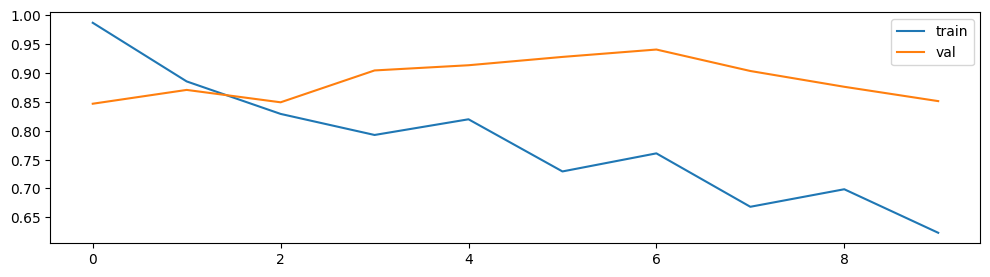

In [242]:
plt.figure(figsize=(12, 3))
plt.plot(losses, label='train')
plt.plot(val_losses, label="val")
plt.legend()
plt.show()

In [243]:
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

# Submission

In [244]:
test_df = pd.read_csv(f"{root_path}/test.csv")
test_ds = PokemonDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=32)

In [245]:
answers = []

model.eval()
for img in tqdm(test_loader):
    img = img.to(device)

    with torch.no_grad():
        pred = model(img)
    
    cls = torch.argmax(pred, dim=1)
    preds = cls.cpu().tolist()

    answers.extend(preds)

answers = le.inverse_transform(answers)

100%|██████████| 6/6 [00:00<00:00, 10.88it/s]


In [246]:
submission = test_df[["SampleID"]]
submission["Type"] = answers

submission.head()

,SampleID,Type
0,699,Ground
1,297,Ground
2,228,Rock
3,337,Poison
4,538,Ice


In [247]:
submission.to_csv(f"{root_path}/submission.csv", index=False)